## Calculate SST and wind composites and NINO3 time series for El Nino and La Nina, for climate Box.

Using ERA5.

In [1]:
# specify True if large ERA5 data sets are not available 
large_datasets_are_available=False

In [2]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from netCDF4 import Dataset
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pickle
import subprocess

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'
fontsize=9
tick_label_fontsize=9
plt.rcParams['font.size'] = fontsize
plt.rcParams.update({'font.size': fontsize})

if large_datasets_are_available:
    vars2save=[]
else:
    print("\nextracting variables: ",end="")
    pickle_filename='Box-ElNino-composites-timeseries-ERA5.pickle'
    savedir='../../Data-for-teaching-staff/Boxes/ENSO/'
    with open(savedir+pickle_filename, 'rb') as file:
            d = pickle.load(file)
            # print information about each extracted variable:
            for key in list(d.keys()):
                print(key,",",end="")
                #print(\"; type=\",type(d[key]))
            globals().update(d)
    print(" done.\n")

# read atmospheric grid information:
if large_datasets_are_available:
    data_dir="/Users/eli/Downloads/"
    file="U10.nc"
    ncfile = Dataset(data_dir+file, 'r');
    lat = ncfile.variables['latitude'][:]
    lon = ncfile.variables['longitude'][:]
    times=ncfile.variables['time'][:]

    # dont use data from partial year in 2020:
    times=times[:-8]
    # open SST file:
    data_dir="/Users/eli/Downloads/"
    file="SST.nc"
    ncfile= Dataset(data_dir+file, 'r');
    SST= ncfile.variables['sst']

    # open U,V files:
    data_dir="/Users/eli/Downloads/"
    file="U10.nc"
    ncfile= Dataset(data_dir+file, 'r');
    U10= ncfile.variables['u10']
    file="V10.nc"
    ncfile= Dataset(data_dir+file, 'r');
    V10 = ncfile.variables['v10']

    # get grid/ time limits:
    Nt,Nz,Ny,Nx=U10.shape

    # save for use if large data are not available:
    vars2save.extend([lon,lat,times,Nt,Nz,Ny,Nx])

    
# calculate dates and month for each day in the record: model times are hours since 1900-01-01 00:00:00.0
timestamp0=datetime.timestamp(datetime.fromisoformat('1900-01-01'))+20*60+40
months=np.zeros(len(times))
dates=[]
idate=-1
for time in times:
    idate=idate+1
    date=datetime.fromtimestamp((time*3600+timestamp0))
    dates.append(date)
    month=dates[idate].month
    months[idate]=month
    #print(time,date,month)
print("calculated months time series.")

# initialize monthly climatoloigy arrays:
U10_climatology=np.zeros((12,Ny,Nx))
V10_climatology=np.zeros((12,Ny,Nx))
SST_climatology=np.zeros((12,Ny,Nx))

if large_datasets_are_available:
    print("dimensions of U10,V10:",U10.shape)
    print("dimensions of SST:",SST.shape)
    print("first time:",dates[0],",last time:",dates[-1])


extracting variables: lon ,lat ,times ,Nt ,Nz ,Ny ,Nx ,NINO34_timeseries ,U10_climatology ,U10_composite_ElNino ,U10_composite_LaNina ,V10_climatology ,V10_composite_ElNino ,V10_composite_LaNina ,SST_climatology ,SST_composite_ElNino ,SST_composite_LaNina , done.

calculated months time series.


/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_24676/4008884086.py:75: RuntimeWarning: overflow encountered in scalar multiply
  date=datetime.fromtimestamp((time*3600+timestamp0))


In [3]:
# define some functions to be able to process all files efficiently without running into memory problems

def calculate_SST_index_timeseries():
    """ calculate a monthly time series of NINO3.4."""
    print("calculate_SST_index_timeseries... ",end="")
    index_timeseries=np.zeros(len(times))
    ilat=np.logical_and(lat<=5,lat>=-5)
    ilon=np.logical_and(lon<=360-120,lon>=360-170)
    # calculate spatial average to find time index:
    index_timeseries=np.nanmean(SST[:,0,ilat,ilon],axis=(1,2))

    # now remove monthly climatology from the NINO3 time series:
    index_monthly_climatology=np.zeros(12)
    for m in range(12):
        index_monthly_climatology[m]=np.mean(index_timeseries[m::12])
        index_timeseries[m::12]= \
           index_timeseries[m::12]-index_monthly_climatology[m]

    print(" done.")
    return index_timeseries


def calculate_composite(variable,mask_timeseries,remove_monthly_climatology,monthly_climatology):
    first_time_read=True
    iavg=0
    for t in range(len(times)):
        #print(t,",",end="")
        # read data:
        if not np.isnan(mask_timeseries[t]):
            #print(t,",",end="")
            if first_time_read:
                first_time_read=False
                variable_avg=1.0*variable[t,0,:,:]
            else:
                variable_avg=variable_avg+variable[t,0,:,:]
            if remove_monthly_climatology:
                variable_avg=variable_avg-monthly_climatology[int(months[t])-1,:,:]

            iavg=iavg+1

    if iavg>0:
        variable_avg=variable_avg/iavg
        variable_avg[variable_avg.mask]=np.nan
    else:
        print("\n\n\n*** error: no times to composite over.\n\n\n")
    #print(" done.")
    
    return variable_avg

print("function defenitions updated.")

function defenitions updated.


## Read pre-calculated NINO3.4 time series from https://psl.noaa.gov/data/correlation/nina34.anom.data that is updated regularly:

In [4]:
# Initialize lists to store monthly values and corresponding times
monthly_values = []
times = []

# Open the data file
with open('../../Data-for-teaching-staff/Boxes/ENSO/nina34.anom.data', 'r') as f:
    # Skip the first line
    next(f)
    for line in f:
        # Split the line into tokens
        tokens = line.strip().split()
        if not tokens:
            continue  # Skip empty lines
        # Convert the first token to float to get the year
        year = float(tokens[0])
        # Stop reading if the year is -99.99
        if year == -99.99:
            break
        # Extract the twelve monthly values
        months = tokens[1:]
        # Check if there are exactly 12 monthly values
        if len(months) != 12:
            print(f"Warning: Year {int(year)} does not have 12 monthly values.")
            continue
        # Process each month's value
        for idx, val in enumerate(months):
            val_float = float(val)
            # Handle -99.99 as NaN
            if val_float == -99.99:
                monthly_values.append(np.nan)
            else:
                monthly_values.append(val_float)
            # Calculate the time for each month
            time = year + (idx + 0.5) / 12
            times.append(time)

# Convert lists to NumPy arrays
monthly_nino34_values_array = np.array(monthly_values)
monthly_nino34_times_array = np.array(times)

print("done.")

done.


## Calculate Nino3.4 from reanalysis data:

In [5]:
# calculate NINO34 time series:
if large_datasets_are_available:
    NINO34_timeseries=calculate_SST_index_timeseries()
    NINO34_timeseries=NINO34_timeseries[0:len(dates)]
    
    # save for use if large data are not available:
    vars2save.extend([NINO34_timeseries])

# prepare mask time series for calculating composites:

mean=np.mean(NINO34_timeseries)
std=np.std(NINO34_timeseries)
print("nino3.4 mean, std=",mean,std)
ElNino_threshold=mean+std*1
LaNina_threshold=mean-std*1

# calculate masks:
ElNino_mask_timeseries=NINO34_timeseries*0+1.0
ElNino_mask_timeseries[NINO34_timeseries<ElNino_threshold]=np.nan
num_ElNino_months=np.nansum(ElNino_mask_timeseries)

LaNina_mask_timeseries=NINO34_timeseries*0+1.0
LaNina_mask_timeseries[NINO34_timeseries>LaNina_threshold]=np.nan
num_LaNina_months=np.nansum(LaNina_mask_timeseries)


print("ElNino_threshold=",ElNino_threshold, ", number of ElNino months=",num_ElNino_months
      ,"=",100*num_ElNino_months/len(NINO34_timeseries),"%");
print("LaNina_threshold=",LaNina_threshold, ", number of LaNina months=",num_LaNina_months
      ,"=",100*num_LaNina_months/len(NINO34_timeseries),"%");

print("done.")

nino3.4 mean, std= 0.000782809844315372 0.914799582561116
ElNino_threshold= 0.9155823924054314 , number of ElNino months= 63.0 = 12.778904665314402 %
LaNina_threshold= -0.9140167727168007 , number of LaNina months= 70.0 = 14.198782961460447 %
done.


In [6]:
# use indices to calculate monthly climatologies and composites:

if large_datasets_are_available:
    print("Calculating monthly climatologies...",end="")
    remove_monthly_climatology=False
    for m in range(0,12):
        print(m,",",end="")
        climatology_mask_timeseries=np.zeros(ElNino_mask_timeseries.shape)*np.nan
        climatology_mask_timeseries[m::12]=1
        monthly_climatology=np.nan
        U10_climatology[m,:,:] = calculate_composite(U10,climatology_mask_timeseries,remove_monthly_climatology,monthly_climatology)
        V10_climatology[m,:,:] = calculate_composite(V10,climatology_mask_timeseries,remove_monthly_climatology,monthly_climatology)
        SST_climatology[m,:,:] = calculate_composite(SST,climatology_mask_timeseries,remove_monthly_climatology,monthly_climatology)
    print(" Done calculating monthly climatologies.")

    # calculate composites for El Nina and La Nina:
    print("Calculating El Nino/ La Nina composites...",end="")
    remove_monthly_climatology=True
    SST_composite_ElNino = calculate_composite(SST,ElNino_mask_timeseries,remove_monthly_climatology,SST_climatology)
    SST_composite_LaNina = calculate_composite(SST,LaNina_mask_timeseries,remove_monthly_climatology,SST_climatology)
    U10_composite_ElNino = calculate_composite(U10,ElNino_mask_timeseries,remove_monthly_climatology,U10_climatology)
    V10_composite_ElNino = calculate_composite(V10,ElNino_mask_timeseries,remove_monthly_climatology,V10_climatology)
    U10_composite_LaNina = calculate_composite(U10,LaNina_mask_timeseries,remove_monthly_climatology,U10_climatology)
    V10_composite_LaNina = calculate_composite(V10,LaNina_mask_timeseries,remove_monthly_climatology,V10_climatology)
    print(" Done calculating El Nino/ La Nina composites.")
    
    # save for use if large data are not available:
    vars2save.extend([U10_climatology,U10_composite_ElNino,U10_composite_LaNina,
                      V10_climatology,V10_composite_ElNino,V10_composite_LaNina,
                      SST_climatology,SST_composite_ElNino,SST_composite_LaNina])
    
print("done.")

done.


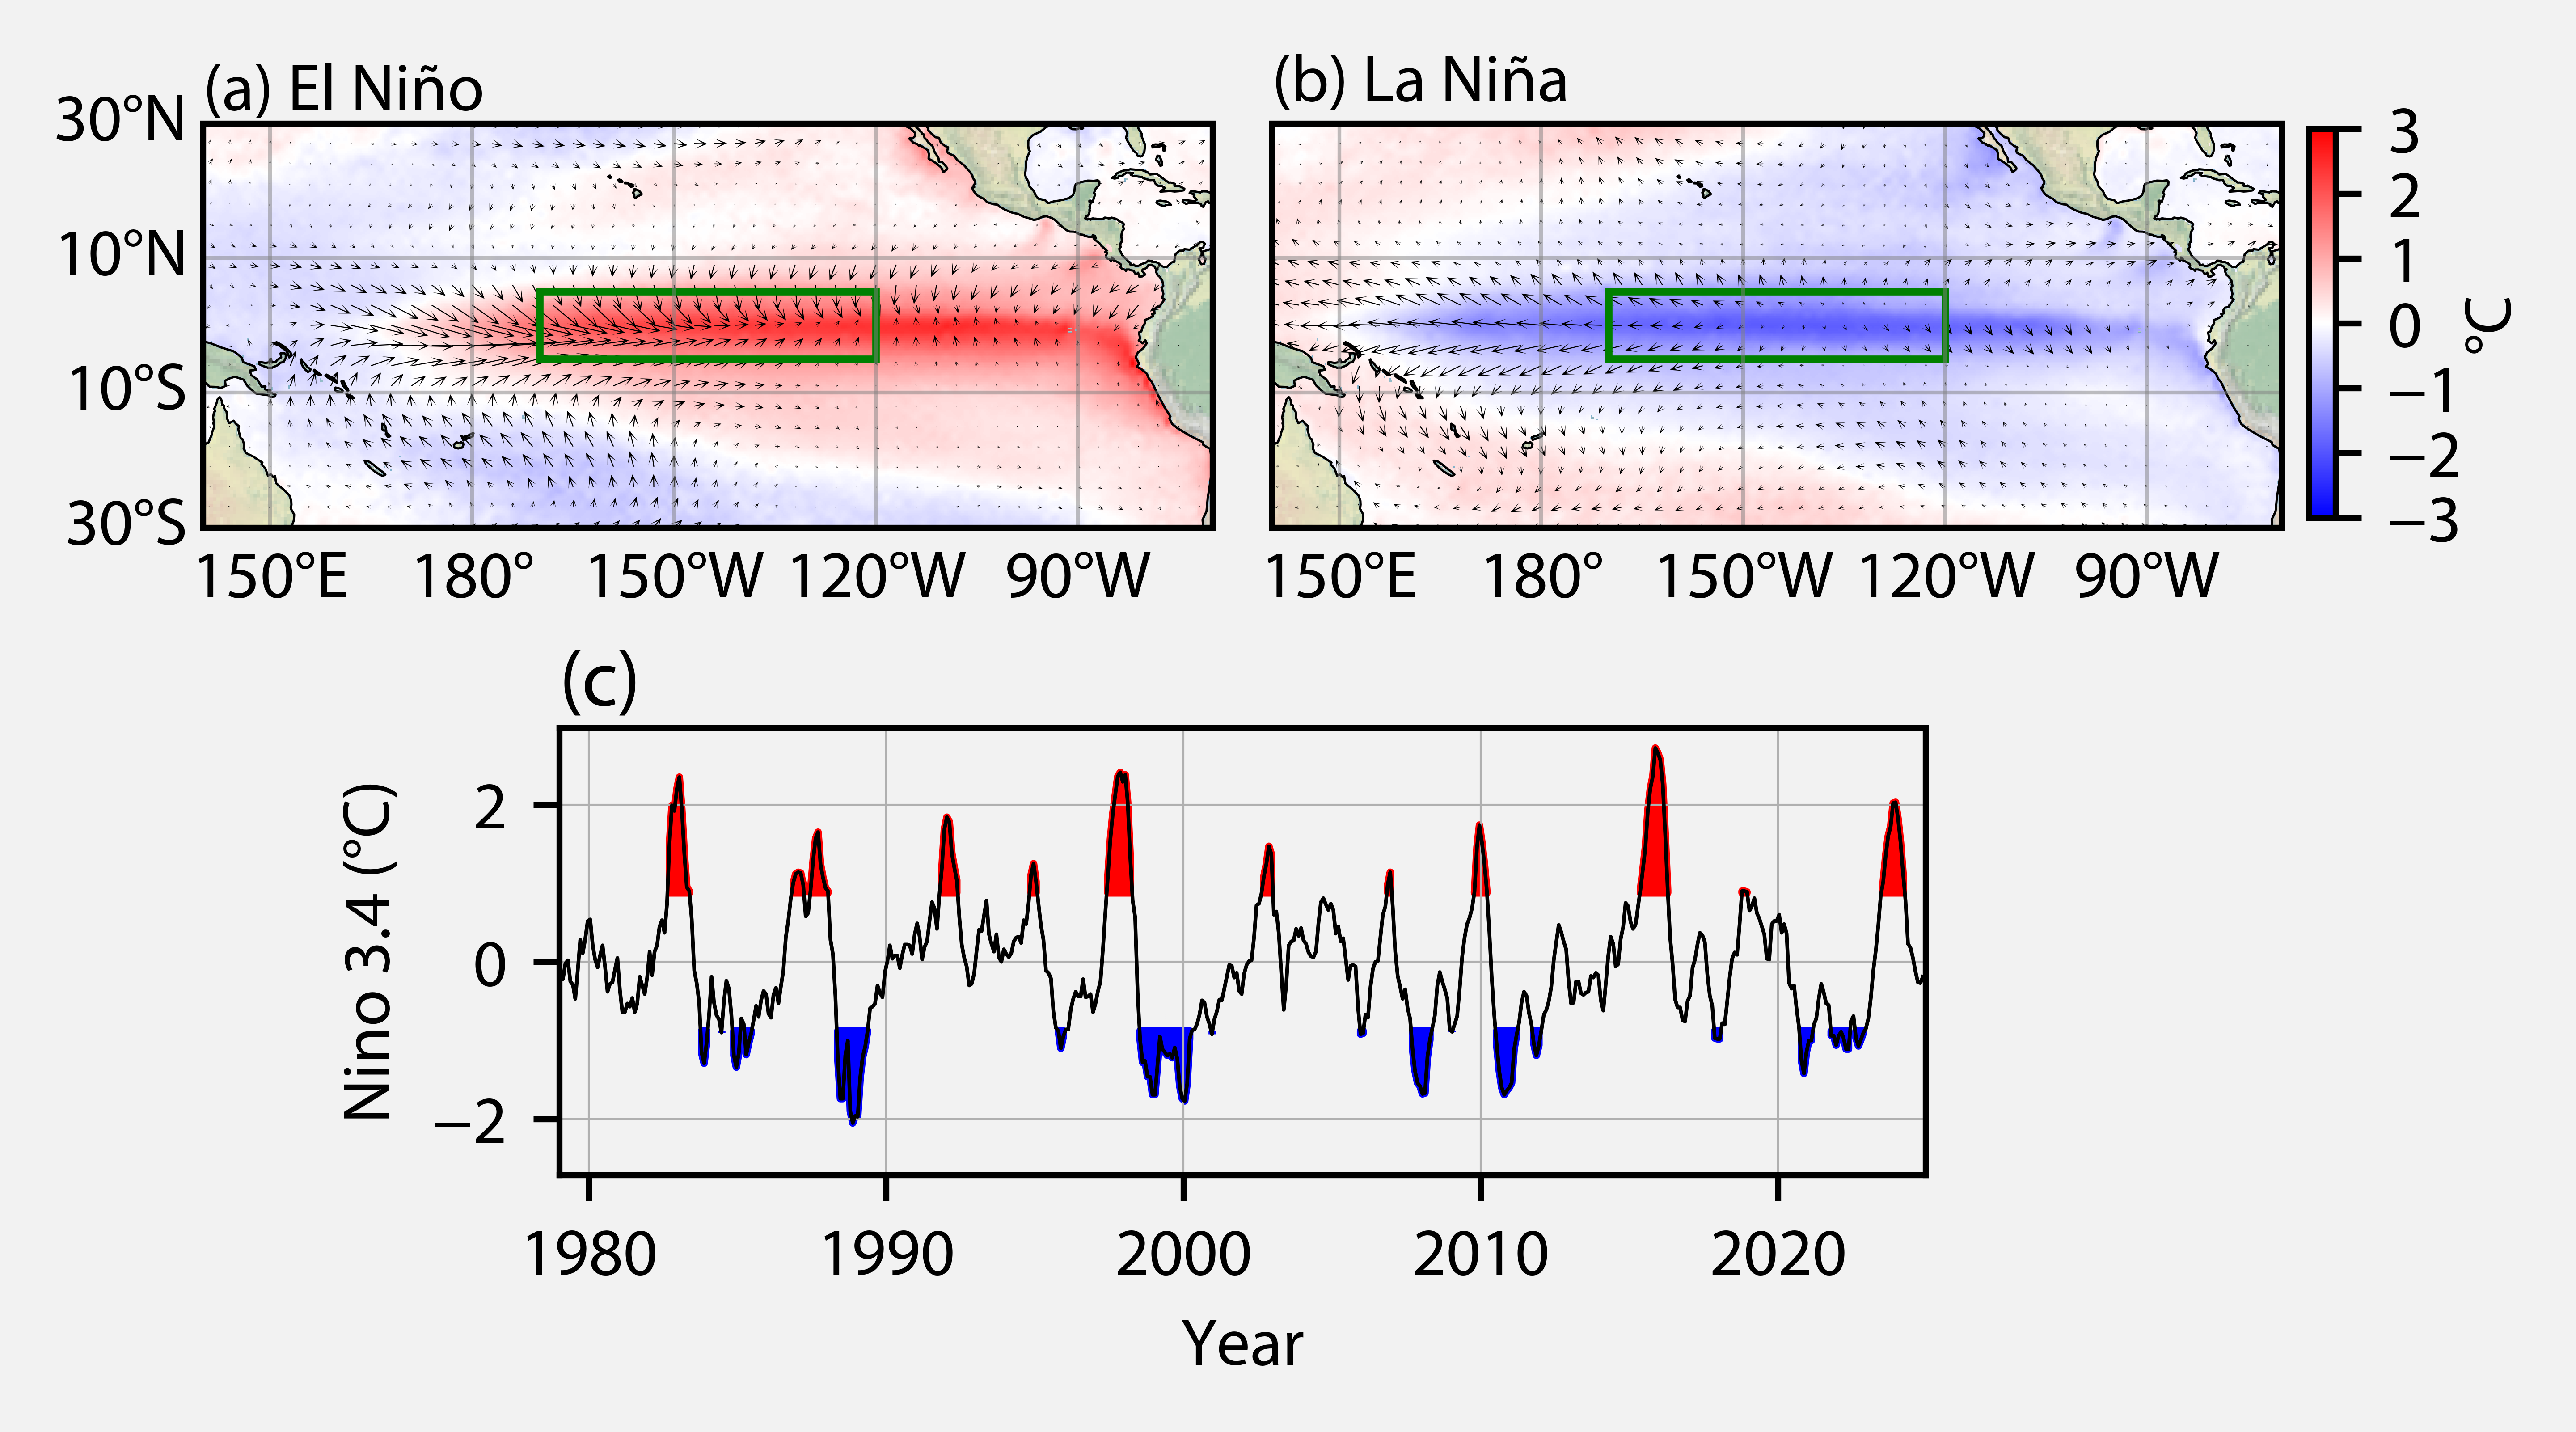

In [7]:
# draw the climatologies and composites:

# add a column to lon/lat arrays to eliminate white gap at dateline:
# for atmospheric plots:
lon1=1.0*lon[-1]+lon[2]-lon[1]; lon1=np.hstack((lon,lon1))

# initialize figure:
projection=ccrs.PlateCarree(central_longitude=0.0);
fig=plt.figure(figsize=(5,2.5),dpi=1200);


# El Nino:
# --------
axes=fig.add_subplot(2,6,(1,3), projection=ccrs.PlateCarree(180))
axes.set_extent([-220.0, -70.0, -30.01, 30.01], crs=ccrs.PlateCarree(0))
axes.coastlines(resolution='110m',lw=0.3)
axes.stock_img()
plt.set_cmap('bwr')
DATA=1.0*SST_composite_ElNino[:,:]
# add a column to DATA array to eliminate white gap at dateline:
DATA1=1.0*DATA[:,0]; 
DATA1.shape=(len(DATA1[:]),1); DATA1=np.hstack((DATA,DATA1))
c=axes.pcolormesh(lon1+180,lat, DATA1[:,:],vmin=-3,vmax=3)
s=12
axes.quiver(lon[::s]+180, lat[::s], U10_composite_ElNino[::s,::s], V10_composite_ElNino[::s,::s]\
            ,scale=80,width=0.001,headwidth=10,headlength=12)
axes.set_title('(a) El Niño',loc="left", pad=-1, fontsize=fontsize)
axes.add_patch(mpatches.Rectangle(xy=[360-170, -5], width=50, height=10
                ,edgecolor="g", lw=1, facecolor='none',transform=ccrs.PlateCarree()))
gl = axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,  
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='-')
gl.xlocator = mticker.FixedLocator([150, 180, -150, -120, -90])
gl.ylocator = mticker.FixedLocator([-30, -10, 10, 30])
gl.rotate_labels=False
gl.xlabel_style = {'size': tick_label_fontsize}
gl.ylabel_style = {'size': tick_label_fontsize}
gl.right_labels = False
gl.top_labels = False
gl.ypadding=2
gl.xpadding=3


# La Nina:
# --------
axes=fig.add_subplot(2,6,(4,6), projection=ccrs.PlateCarree(180))
axes.set_extent([-220.0, -70.0, -30.01, 30.01], crs=ccrs.PlateCarree())
axes.coastlines(resolution='110m',lw=0.3)
axes.stock_img()
plt.set_cmap('bwr')
DATA=1.0*SST_composite_LaNina[:,:]
# add a column to DATA array to eliminate white gap at dateline:
DATA1=1.0*DATA[:,0]; 
DATA1.shape=(len(DATA1[:]),1); DATA1=np.hstack((DATA,DATA1))
c=axes.pcolormesh(lon1+180,lat, DATA1[:,:],vmin=-3,vmax=3)
s=12
axes.quiver(lon[::s]+180, lat[::s], U10_composite_LaNina[::s,::s], V10_composite_LaNina[::s,::s]\
            ,scale=80,width=0.001,headwidth=10,headlength=12)
axes.set_title('(b) La Niña',loc="left",pad=3,fontsize=fontsize)
axes.add_patch(mpatches.Rectangle(xy=[360-170, -5], width=50, height=10
                ,edgecolor="g", lw=1, facecolor='none',transform=ccrs.PlateCarree()))
gl = axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='-')
gl.xlocator = mticker.FixedLocator([150, 180, -150, -120, -90])
gl.ylocator = mticker.FixedLocator([-30, -10, 10, 30])
gl.rotate_labels=False
gl.xlabel_style = {'size': tick_label_fontsize}
gl.left_labels = False
gl.right_labels = False
gl.top_labels = False
gl.xpadding=3

# joint colorbar for both upper panels:
ax2 = fig.add_axes([0.91, 0.64, 0.01, 0.29])
clb=fig.colorbar(c,cax=ax2, ticks=np.arange(-3,4,1),anchor=(0.3,0.5))
clb.set_label('°C',labelpad=0)



# NINO3 time series:
# ------------------
# at this point used pre-calculatee NOAA nino3.4 
# instead of the one I calculated from reanalysis:
NINO34_timeseries=np.array(monthly_nino34_values_array)
dates=np.array(monthly_nino34_times_array)
std=np.nanstd(NINO34_timeseries)
axes=fig.add_subplot(2,6,(8,11))
axes.plot(dates,NINO34_timeseries,lw=0.5,label="NINO3.4",color="k")
y1=1.0*NINO34_timeseries
y1[NINO34_timeseries<std]=np.nan
y1=y1*0+std
axes.fill_between(dates, y1=y1, y2=NINO34_timeseries, color="r")
y2=1.0*NINO34_timeseries
y2[NINO34_timeseries>-std]=np.nan
y2=y2*0-std
axes.fill_between(dates, y1=NINO34_timeseries, y2=y2, color="b")
axes.set_xlabel("Year")
axes.set_ylabel("Nino 3.4 (°C)")
plt.xlim([1979,dates[-1]]);
axes.grid(lw=0.25);
axes.set_title("(c)", pad=3, loc="left")
axes.set_facecolor('#f2f2f2')
fig.patch.set_facecolor('#f2f2f2')

# finalize and show plot:
# plt.tight_layout(pad=1, h_pad=0.2, w_pad=-6.8)
plt.subplots_adjust(bottom=0.15,top=0.95,hspace=0.4)

plt.show()
# fig.savefig("Output/Box-ElNino-composites-timeseries-ERA5.pdf",facecolor='#f2f2f2'
#            ,bbox_inches='tight',pad_inches = 0);
filename="Box-ElNino-composites-timeseries-ERA5"
fig.savefig("Output/"+filename+".png"
            ,bbox_inches="tight", pad_inches=0.02)
png = "Output/"+filename+".png"
pdf = "Output/"+filename+".pdf"
subprocess.run(["magick", png, pdf], check=True);

In [8]:
# pickle all vars to save:
def pickle_vars(fileName, env, variables):
    d = dict([(x, env[x]) for v in variables for x in env if v is env[x]])
    with open(fileName, 'wb') as f:
        pickle.dump(d, f)

if large_datasets_are_available:
    pickle_vars('Output/Box-ElNino-composites-timeseries-ERA5.pickle',locals(),vars2save)

print("done.")

done.
